<div style="border:solid green 2px; padding: 20px">
    
<b>Михаил, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Меня зовут Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

<div style="border:solid blue 3px; padding: 20px">
<div class="alert alert-block alert-success">✔️
    

__Коментарий от ревьюера №2__
    

Михаил, спасибо за доработку! Сейчас проект можно принимать - основные замечания закрыты, качество модели выше целевого порога, итоговый pipeline сохранен, а полный сценарий инференса на данных без age_category проверен.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №2__

Класс OutlierCapper сейчас определен прямо в ноутбуке и входит в сохраненный pipeline. В текущей сессии артефакт загружается корректно, но в другом окружении после чистого перезапуска joblib может не найти определение класса

На будущее лучше вынести OutlierCapper в отдельный файл, например custom_transformers.py, импортировать его в ноутбук, а затем заново сохранить pipeline. Также стоит обновить финальные выводы под актуальные значения метрик последнего запуска: F1_macro = 0.8307 на тесте и 0.8151 на кросс-валидации.

# Определение возрастной категории пользователей по данным о веб-активности

*Проект по линейным моделям машинного обучения для компании «Йети»*

Автор: Якунин Михаил

Дата: 11 июня 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint13_Yeti_Age_Prediction.git***

## Цель проекта

Разработать модель машинного обучения, которая на основе анонимизированных данных о поведении пользователей в интернете (логи посещений сайтов, активность с рекламой, тип устройства, глубина просмотра, использование облачных сервисов) автоматически определяет возрастную категорию пользователя.

Целевая переменная — age_category с пятью классами:
- 0: младше 18 лет
- 1: 18–25 лет
- 2: 26–40 лет
- 3: 41–55 лет
- 4: 56 лет и старше

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Плюс, что сразу зафиксирован целевой порог качества macro F1 >= 0.75

## Задача проекта

Построить и обучить линейный классификатор (LogisticRegression или SVC) для предсказания возрастной категории пользователя по его цифровому следу. Обеспечить macro F1 ≥ 0.75, создать признаки из логов посещений, правильно разделить выборку, сохранить пайплайн и функцию объединения данных для внедрения.

## Описание данных

В проекте используются шесть CSV-файлов, каждый из которых содержит различные аспекты поведения пользователей. Все данные анонимизированы и не содержат прямой идентификации личности.

**1. `users` (целевая переменная)**
- `user_id` — уникальный идентификатор пользователя.
- `age_category` — целевая переменная (класс возраста):
  - `0`: младше 18 лет
  - `1`: 18–25 лет
  - `2`: 26–40 лет
  - `3`: 41–55 лет
  - `4`: 56 лет и старше

**2. `visits` (лог посещений сайтов)**
- `date` — дата посещения.
- `daytime` — время суток (утро, день, вечер, ночь).
- `session_id` — уникальный идентификатор сессии.
- `user_id` — идентификатор пользователя.
- `website_category` — анонимизированная категория сайта (десятки категорий).

**3. `ads_activity` (активность с рекламой)**
- `user_id`
- `ads_activity` — частота кликов по рекламе (очень редко, редко, умеренно, часто, очень часто).

**4. `surf_depth` (глубина просмотра)**
- `user_id`
- `surf_depth` — категория глубины перехода по сайтам (поверхностно, средне, глубоко).

**5. `primary_device` (основное устройство)**
- `user_id`
- `primary_device` — тип основного устройства для выхода в интернет (например, десктоп, мобильный телефон, планшет).

**6. `cloud_usage` (использование облачных сервисов)**
- `user_id`
- `cloud_usage` — бинарный признак (`True` / `False`), указывающий, пользуется ли пользователь облачными ресурсами (например, Яндекс 360).

**Особенности:**
- Таблица `visits` содержит множество строк на одного пользователя (история посещений). Остальные таблицы имеют по одной записи на `user_id`.
- При объединении таблиц с помощью `left join` могут возникать пропуски (`NaN`) для пользователей, отсутствующих в одной из дополнительных таблиц. Это нормально и будет обработано на этапе импутации.
- Целевая переменная может быть несбалансированной — это будет проверено на этапе EDA.

## Содержание <a id=content></a>

1. [Подготовка среды и библиотек](#1)
2. [Исследовательский анализ данных (EDA)](#2)
3. [Предобработка данных и создание новых признаков](#3)
4. [Разделение данных (стратифицированное по пользователям)](#4)
5. [Предобработка признаков (пайплайн)](#5)
6. [Обучение базовой модели (Baseline)](#6)
7. [Обучение основных моделей и подбор гиперпараметров](#7)
8. [Оценка на тестовой выборке](#8)
9. [Подготовка артефактов для внедрения](#9)
10. [Итоговый отчёт](#10)

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


В описании написано, что в данных могут быть пропуски, особенно в cloud_usage. В исходных таблицах явных NaN нет, но пропуски появляются после объединения, потому что не во всех таблицах есть все пользователи. Лучше так и сформулировать

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

Исправил</div>

## [Этап 1. Подготовка среды и библиотек <a id=1></a>](#content)

### В этом разделе:
*   Устанавливаем и импортируем все необходимые библиотеки (pandas, numpy, sklearn, matplotlib, seaborn и др.)
*   Задаем константные параметры (random_state, пути к данным)
*   Настраиваем параметры отображения pandas и стили графиков

In [1]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [2]:
# Импорт библиотек

# Базовые научные и вычислительные библиотеки
import numpy as np                
import pandas as pd               
import datetime                   
from datetime import datetime
from feature_builder import preprocess_data

# Визуализация данных
import matplotlib.pyplot as plt   
import seaborn as sns             

# Статистический анализ и машинное обучение
import phik                       
import joblib                    
import sklearn  

# Предобработка данных и пайплайны (sklearn)
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Модели машинного обучения
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC

# Метрики и оценка качества
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    make_scorer
)

In [3]:
# Устанавливаем константные параметры
RANDOM_STATE = 988

# Пути к данным
DATA_PATH = 'data/'
FILES = {
    'users': 'ds_s13_users.csv',
    'visits': 'ds_s13_visits.csv',
    'ads': 'ads_activity.csv',
    'surf': 'surf_depth.csv',
    'device': 'primary_device.csv',
    'cloud': 'cloud_usage.csv'
}

In [4]:
# Настройка параметров отображения pandas и стилей графиков
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

### Промежуточные выводы

*   Импортированы все необходимые библиотеки для анализа данных, визуализации и машинного обучения (`pandas`, `numpy`, `sklearn`, `matplotlib`, `seaborn`, `phik`, `joblib`).
*   Задан параметр `RANDOM_STATE = 988` для обеспечения воспроизводимости результатов.
*   Настроены пути к данным и параметры отображения pandas для удобного просмотра таблиц.
*   Среда полностью подготовлена для загрузки, анализа и моделирования данных.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Импорты собраны в начале, задан RANDOM_STATE, настроены пути к данным и параметры отображения

## [Этап 2. Исследовательский анализ данных (EDA) <a id=2></a>](#content)

### В этом разделе:
*   Загружаем и изучаем структуру всех CSV-файлов
*   Анализируем распределение целевой переменной (age_category)
*   Исследуем пропуски и дубликаты в данных
*   Анализируем распределение признаков по возрастным категориям
*   Исследуем выбросы и распределения непрерывных признаков
*   Анализируем корреляцию между признаками (Phi-K матрица)

### 2.1 Загрузка данных и первичная информация о данных

In [5]:
# Загружаем все CSV-файлы
users = pd.read_csv(DATA_PATH + FILES['users'])
visits = pd.read_csv(DATA_PATH + FILES['visits'])
ads = pd.read_csv(DATA_PATH + FILES['ads'])
surf = pd.read_csv(DATA_PATH + FILES['surf'])
device = pd.read_csv(DATA_PATH + FILES['device'])
cloud = pd.read_csv(DATA_PATH + FILES['cloud'])

# Создание словаря c датафреймами
dataframes = {
    'users': users,
    'visits': visits,
    'ads': ads,
    'surf': surf,
    'device': device,
    'cloud': cloud
}

In [6]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [7]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: users


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,5913,5826,ee47-db686342605ccf3ce244-088514e9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_category,5913.0,NaN,NaN,NaN,2.441569,1.380322,0.0,2.0,3.0,4.0,4.0



Информация о таблице: visits


...

,count,unique,top,freq
user_id,5669,5669,d602-ec060db7597a6b8cd4e7-aa625896,1
primary_device,5669,4,смартфон,3083



Информация о таблице: cloud


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


,count,unique,top,freq
user_id,5680,5680,a1e4-91c8a52eb855595e653f-298ce305,1
cloud_usage,5680,2,True,2951


### 2.2 Анализ целевой переменной

In [8]:
# Распределение классов
age_counts = users['age_category'].value_counts().sort_index()
age_percent = users['age_category'].value_counts(normalize=True).sort_index() * 100

Распределение age_category:
  Категория 0: 863 (14.6%)
  Категория 1: 520 (8.8%)
  Категория 2: 1467 (24.8%)
  Категория 3: 1269 (21.5%)
  Категория 4: 1794 (30.3%)


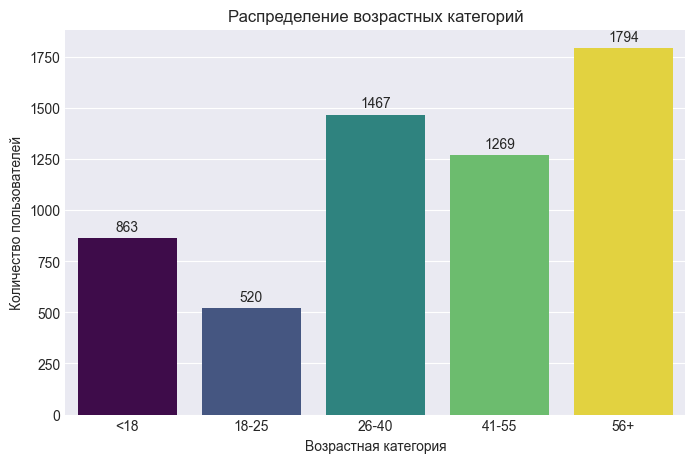

In [9]:
print("Распределение age_category:")
for cat, count, pct in zip(age_counts.index, age_counts.values, age_percent.values):
    print(f"  Категория {cat}: {count} ({pct:.1f}%)")

# Построение графика
plt.figure(figsize=(8,5))
ax = sns.countplot(data=users, x='age_category', hue='age_category', 
                   palette='viridis', legend=False)
plt.title('Распределение возрастных категорий')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество пользователей')
plt.xticks(ticks=range(5), labels=['<18', '18-25', '26-40', '41-55', '56+'])

# Добавление значений на столбцы
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.show()

### 2.3 Аназиз данных

#### Анализ пропусков и дубликатов в данных

In [10]:
# Анализ пропусков и дубликатов в данных
def missing_duplicates_report(df, name):
    print(f"\n{'='*50}")
    print(f"Таблица: {name}")
    print(f"{'='*50}")
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
    
    # Пропуски
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_report = pd.DataFrame({'пропусков': missing, 'доля (%)': missing_pct})
    missing_report = missing_report[missing_report['пропусков'] > 0]
    if len(missing_report) > 0:
        print("Пропуски:")
        print(missing_report)
    else:
        print("Пропуски отсутствуют.")
    
    # Явные дубликаты (полностью одинаковые строки)
    explicit_dups = df.duplicated().sum()
    print(f"Явные дубликаты (полностью совпадающие строки): {explicit_dups}")
    
    # Дубликаты по user_id (если колонка существует)
    if 'user_id' in df.columns:
        dup_by_user = df['user_id'].duplicated().sum()
        print(f"Дубликаты по 'user_id': {dup_by_user}")

In [11]:
# Вывод пропусков и дубликатов
for name, df in dataframes.items():
    missing_duplicates_report(df, name)


Таблица: users
Размер: 5913 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 87
Дубликаты по 'user_id': 87

Таблица: visits
Размер: 1065745 строк, 5 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 15750
Дубликаты по 'user_id': 1059919

Таблица: ads
Размер: 5826 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 233
Дубликаты по 'user_id': 233

Таблица: surf
Размер: 5715 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0

Таблица: device
Размер: 5669 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0

Таблица: cloud
Размер: 5680 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0


In [12]:
# Анализ неявные дубликаты
def check_implicit_duplicates(df, name):
    user_counts = df['user_id'].value_counts()
    non_unique = user_counts[user_counts > 1]
    
    print(f"\n{'='*50}")
    print(f"Таблица: {name}")
    print(f"{'='*50}")
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
    if len(non_unique) == 0:
        print(f"Все user_id уникальны (нет неявных дубликатов).\n")
    else:
        print(f"Найдено {len(non_unique)} user_id с дубликатами.")
        print(f"Максимальное число повторений: {non_unique.max()}")

In [13]:
# Применяем ко всем таблицам, кроме visits (там ожидаются множественные записи)
print("\nАнализ неявных дубликатов (несколько записей на одного user_id)")
for name, df in dataframes.items():
    check_implicit_duplicates(df, name)

# Для visits неявные дубликаты — это норма, поэтому пропускаем
print("Таблица visits: множественные записи на user_id ожидаемы и корректны.")


Анализ неявных дубликатов (несколько записей на одного user_id)

Таблица: users
Размер: 5913 строк, 2 столбцов
Найдено 87 user_id с дубликатами.
Максимальное число повторений: 2

Таблица: visits
Размер: 1065745 строк, 5 столбцов
Найдено 5826 user_id с дубликатами.
Максимальное число повторений: 853

Таблица: ads
Размер: 5826 строк, 2 столбцов
Найдено 233 user_id с дубликатами.
Максимальное число повторений: 2

Таблица: surf
Размер: 5715 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).


Таблица: device
Размер: 5669 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).


Таблица: cloud
Размер: 5680 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).

Таблица visits: множественные записи на user_id ожидаемы и корректны.


In [14]:
# Уникальные значения категорий и времени суток
print("Уникальные website_category:", visits['website_category'].nunique())
print("Уникальные daytime:", list(visits['daytime'].unique()))
print("Распределение daytime:", visits['daytime'].value_counts())
print('=' * 50)

# Анализ дат
visits['date'] = pd.to_datetime(visits['date'])
print(f"Период дат: с {visits['date'].min()} по {visits['date'].max()}")
print(f"Количество уникальных дней: {visits['date'].nunique()}")
print('=' * 50)

# Количество сессий на пользователя (статистика)
sessions_per_user = visits.groupby('user_id')['session_id'].nunique()
print("Статистика по количеству сессий на пользователя:")
print(sessions_per_user.describe())

Уникальные website_category: 20
Уникальные daytime: ['вечер', 'день', 'ночь', 'утро']
Распределение daytime: daytime
день     389052
вечер    382098
утро     211500
ночь      83095
Name: count, dtype: int64
Период дат: с 2025-11-01 00:00:00 по 2025-11-14 00:00:00
Количество уникальных дней: 14
Статистика по количеству сессий на пользователя:
count    5826.000000
mean      180.225712
std        75.186802
min       100.000000
25%       124.000000
50%       167.000000
75%       213.000000
max       839.000000
Name: session_id, dtype: float64


#### Анализ распределения признаков по возрастным категориям

In [15]:
# Объединим users с одной из таблиц, например с ads_activity
merged = users.merge(ads, on='user_id', how='left')
# Кросс-таблица
cross_ads = pd.crosstab(merged['age_category'], merged['ads_activity'], normalize='index') * 100
print("Распределение ads_activity по возрастным категориям (%):")
print(cross_ads.round(1))

# Аналогично для cloud_usage
merged_cloud = users.merge(cloud, on='user_id', how='left')
# Заменим пропуски на False (если есть)
merged_cloud['cloud_usage'] = merged_cloud['cloud_usage'].fillna(False)
cross_cloud = pd.crosstab(merged_cloud['age_category'], merged_cloud['cloud_usage'], normalize='index') * 100
print("\nРаспределение cloud_usage по возрастным категориям (%):")
print(cross_cloud.round(1))

# Для surf_depth
merged_surf = users.merge(surf, on='user_id', how='left')
cross_surf = pd.crosstab(merged_surf['age_category'], merged_surf['surf_depth'], normalize='index') * 100
print("\nРаспределение surf_depth по возрастным категориям (%):")
print(cross_surf.round(1))

# Для primary_device
merged_device = users.merge(device, on='user_id', how='left')
cross_device = pd.crosstab(merged_device['age_category'], merged_device['primary_device'], normalize='index') * 100
print("\nРаспределение primary_device по возрастным категориям (%):")
print(cross_device.round(1))

Распределение ads_activity по возрастным категориям (%):
ads_activity  очень редко  очень часто  редко  умеренно  часто
age_category                                                  
0                    23.8          3.9   34.9      27.3   10.0
1                    14.0          4.4   30.6      36.3   14.6
2                     5.2          5.0   21.1      41.6   27.1
3                    11.1          4.2   23.5      36.1   25.1
4                    21.9          3.3   36.2      24.4   14.3

Распределение cloud_usage по возрастным категориям (%):
cloud_usage   False  True 
age_category              
0              65.6   34.4
1              38.5   61.5
2              32.4   67.6
3              45.3   54.7
4              61.4   38.6

Распределение surf_depth по возрастным категориям (%):
surf_depth    глубоко  поверхностно  средне
age_category                               
0                10.2          52.6    37.2
1                15.9          39.1    45.0
2                20.6   

In [16]:
age_labels = ['<18', '18-25', '26-40', '41-55', '56+']
age_categories = [0, 1, 2, 3, 4]

# Функция для визуализации категориального признака
def plot_categorical_feature(users_df, feature_df, feature_col, feature_name, order=None, top_n=None, fillna_value=None):
    merged = users_df.merge(feature_df, on='user_id', how='left')
    
    if fillna_value is not None:
        merged[feature_col] = merged[feature_col].fillna(fillna_value)

    if top_n is not None and feature_col in merged.columns:
        top_values = merged[feature_col].value_counts().head(top_n).index
        merged = merged[merged[feature_col].isin(top_values)]

    merged = merged.dropna(subset=[feature_col])

    if order is None and feature_col in merged.columns:
        order = sorted(merged[feature_col].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Абсолютные значения
    sns.countplot(data=merged, x='age_category', hue=feature_col, 
                  hue_order=order, ax=axes[0])
    axes[0].set_title(f'{feature_name} по возрастным категориям (абсолютные значения)')
    axes[0].set_xlabel('Возрастная категория')
    axes[0].set_ylabel('Количество пользователей')
    axes[0].set_xticks(range(len(age_labels)))
    axes[0].set_xticklabels(age_labels)
    axes[0].legend(title=feature_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # График 2: Нормализованные доли (в процентах)
    cross_tab = pd.crosstab(merged['age_category'], merged[feature_col], normalize='index') * 100
    if order is not None:
        cross_tab = cross_tab[[c for c in order if c in cross_tab.columns]]
    cross_tab.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
    axes[1].set_title(f'{feature_name} по возрастным категориям (нормировано, %)')
    axes[1].set_xlabel('Возрастная категория')
    axes[1].set_ylabel('Доля пользователей (%)')
    axes[1].set_xticks(range(len(age_labels)))
    axes[1].set_xticklabels(age_labels)
    axes[1].legend(title=feature_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Функция для бинарного признака (специально для cloud_usage)
def plot_binary_feature(users_df, feature_df, feature_col, feature_name, fillna_value=False):
    merged = users_df.merge(feature_df, on='user_id', how='left')
    
    if fillna_value is not None:
        merged[feature_col] = merged[feature_col].fillna(fillna_value)
    
    merged = merged.dropna(subset=[feature_col])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Абсолютные значения
    sns.countplot(data=merged, x='age_category', hue=feature_col, ax=axes[0])
    axes[0].set_title(f'{feature_name} по возрастным категориям (абсолютные значения)')
    axes[0].set_xlabel('Возрастная категория')
    axes[0].set_ylabel('Количество пользователей')
    axes[0].set_xticks(range(len(age_labels)))
    axes[0].set_xticklabels(age_labels)
    axes[0].legend(title=feature_name, labels=['Нет', 'Да'])
    
    # График 2: Нормализованные доли (в процентах)
    cross_tab = pd.crosstab(merged['age_category'], merged[feature_col], normalize='index') * 100
    cross_tab.columns = ['Нет', 'Да']
    cross_tab.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff7f0e', '#2ca02c'])
    axes[1].set_title(f'{feature_name} по возрастным категориям (нормировано, %)')
    axes[1].set_xlabel('Возрастная категория')
    axes[1].set_ylabel('Доля пользователей (%)')
    axes[1].set_xticks(range(len(age_labels)))
    axes[1].set_xticklabels(age_labels)
    axes[1].legend(title=feature_name)
    
    plt.tight_layout()
    plt.show()

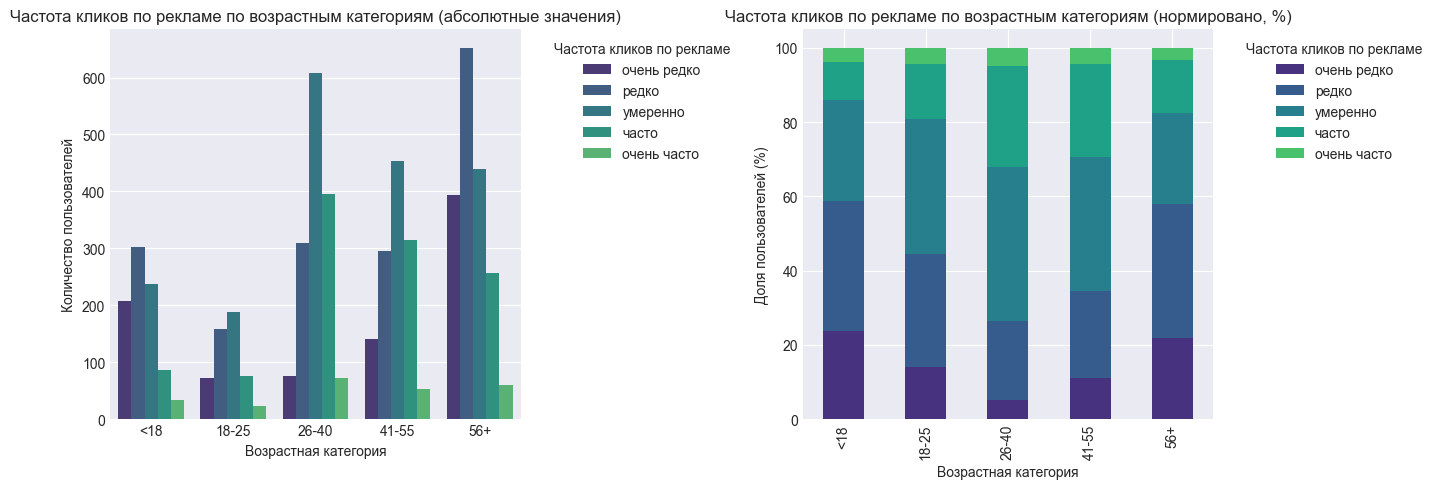

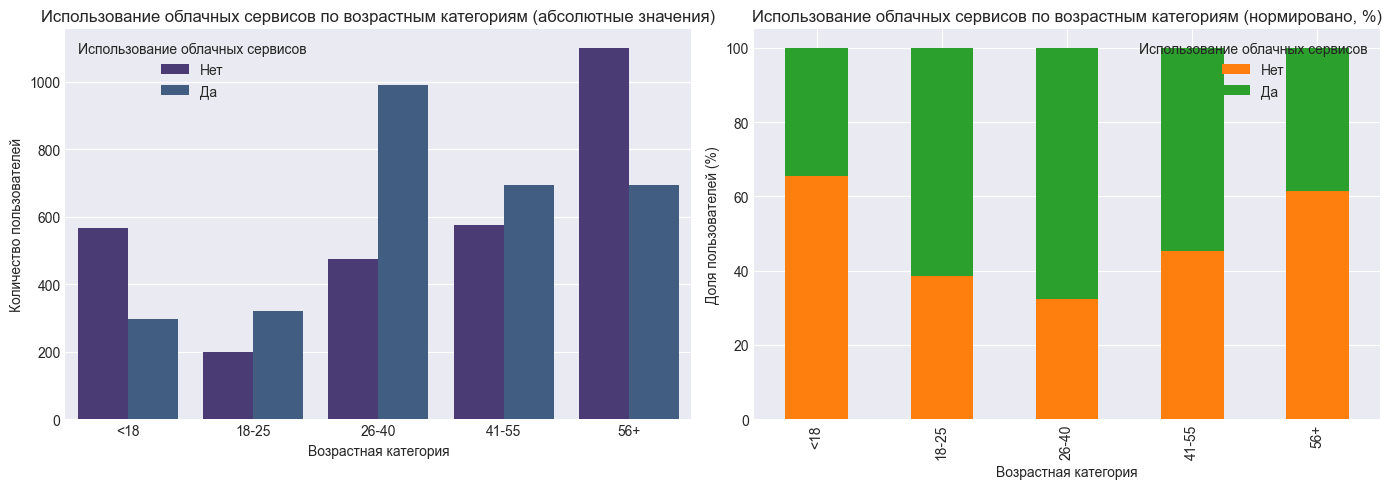

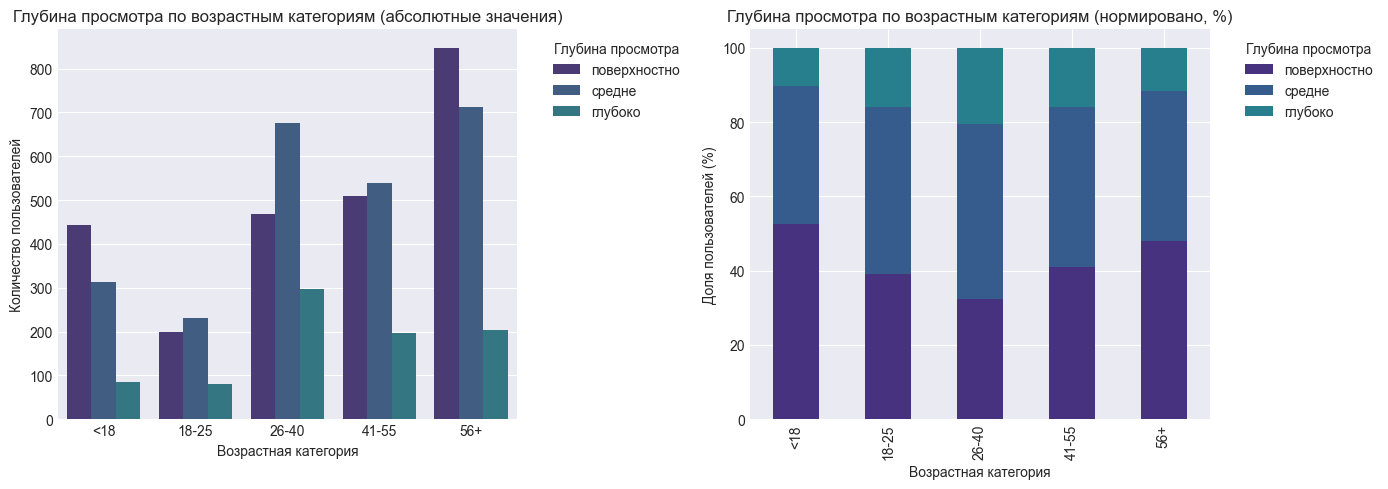

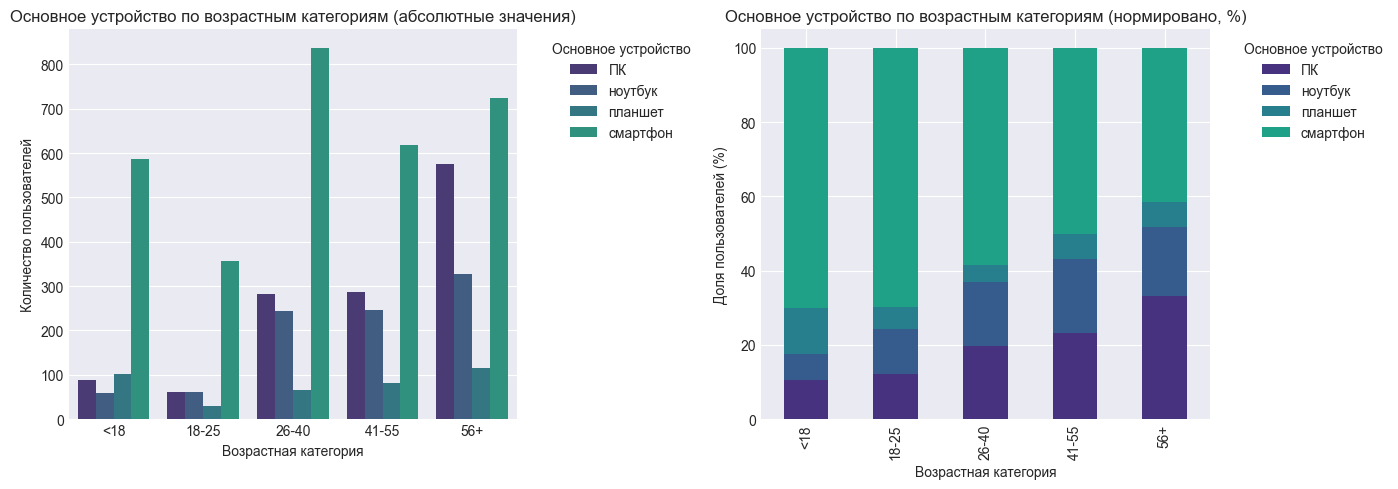

In [17]:
# Анализ ads_activity (частота кликов по рекламе)
order_ads = ['очень редко', 'редко', 'умеренно', 'часто', 'очень часто']
plot_categorical_feature(users, ads, 'ads_activity', 'Частота кликов по рекламе',order=order_ads)

# Анализ cloud_usage (использование облачных сервисов)
plot_binary_feature(users, cloud, 'cloud_usage', 'Использование облачных сервисов',fillna_value=False)

# Анализ surf_depth (глубина просмотра)
order_depth = ['поверхностно', 'средне', 'глубоко']
plot_categorical_feature(users, surf, 'surf_depth', 'Глубина просмотра', order=order_depth)

# Анализ primary_device (основное устройство) — только топ-5 устройств
plot_categorical_feature(users, device, 'primary_device', 'Основное устройство', top_n=5)

#### Анализ выбросов и распределений для непрерывных признаков

In [18]:
# Функция для анализа числового признака (распределение + выбросы)
def analyze_numeric_distribution(data, user_col, value_col, name, bins=50):
    data_clean = data.drop_duplicates(subset=[user_col, value_col] if value_col in data.columns else None)

    if value_col == 'count_visits':
        grouped = data.groupby(user_col).size().rename('value')
    elif value_col == 'count_sessions':
        grouped = data.groupby(user_col)['session_id'].nunique().rename('value')
    elif value_col == 'unique_categories':
        grouped = data.groupby(user_col)['website_category'].nunique().rename('value')
    elif value_col == 'active_days':
        data['date'] = pd.to_datetime(data['date'])
        grouped = data.groupby(user_col)['date'].nunique().rename('value')
    else:
        grouped = data[value_col]
    
    values = grouped.values
    
    print(f"\n{'='*50}")
    print(f"Анализ признака: {name}")
    print(f"{'='*50}")
    print(f"Количество пользователей: {len(values)}")
    print(f"Среднее: {np.mean(values):.2f}")
    print(f"Медиана: {np.median(values):.2f}")
    print(f"Стандартное отклонение: {np.std(values):.2f}")
    print(f"Min: {np.min(values)}")
    print(f"Max: {np.max(values)}")
    
    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = values[(values < lower_bound) | (values > upper_bound)]
    print(f"\nВыбросы (IQR метод, коэффициент 1.5):")
    print(f"  Нижняя граница: {lower_bound:.2f}")
    print(f"  Верхняя граница: {upper_bound:.2f}")
    print(f"  Количество выбросов: {len(outliers)} ({100*len(outliers)/len(values):.1f}%)")
    if len(outliers) > 0:
        print(f"  Диапазон выбросов: {np.min(outliers):.2f} — {np.max(outliers):.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Гистограмма распределения
    axes[0].hist(values, bins=bins, edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(values), color='red', linestyle='--', label=f'Среднее: {np.mean(values):.1f}')
    axes[0].axvline(np.median(values), color='green', linestyle='--', label=f'Медиана: {np.median(values):.1f}')
    axes[0].set_title(f'Распределение {name}')
    axes[0].set_xlabel(name)
    axes[0].set_ylabel('Частота')
    axes[0].legend()
    
    # Boxplot (для наглядного поиска выбросов)
    axes[1].boxplot(values, vert=True)
    axes[1].set_title(f'Boxplot {name}')
    axes[1].set_ylabel(name)
    axes[1].set_xticklabels([name])
    
    plt.tight_layout()
    plt.show()


Анализ признака: количество посещений сайтов
Количество пользователей: 5826
Среднее: 182.93
Медиана: 169.00
Стандартное отклонение: 76.38
Min: 100
Max: 853

Выбросы (IQR метод, коэффициент 1.5):
  Нижняя граница: -10.50
  Верхняя граница: 353.50
  Количество выбросов: 187 (3.2%)
  Диапазон выбросов: 354.00 — 853.00


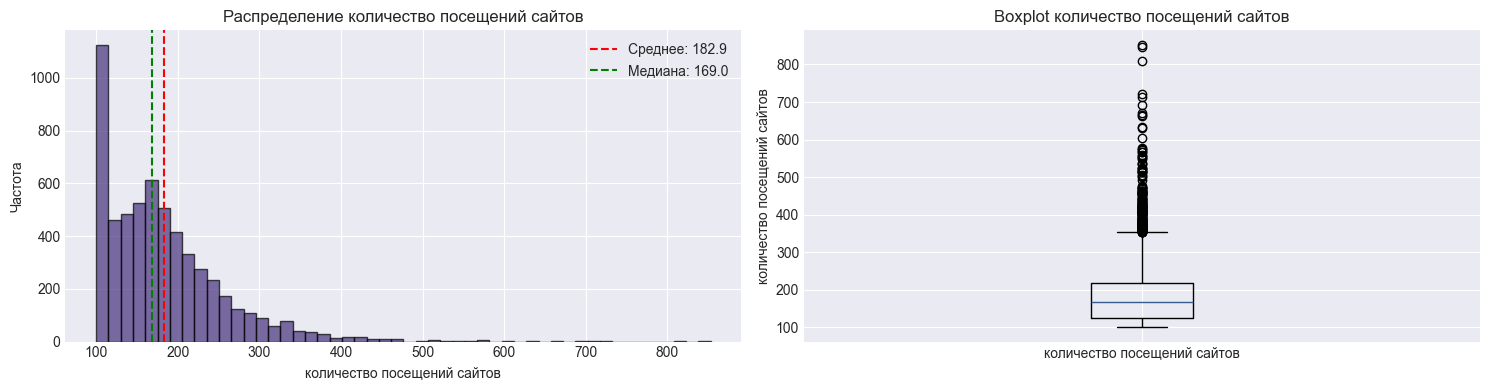


Анализ признака: количество сессий
Количество пользователей: 5826
Среднее: 180.23
Медиана: 167.00
Стандартное отклонение: 75.18
Min: 100
Max: 839

Выбросы (IQR метод, коэффициент 1.5):
  Нижняя граница: -9.50
  Верхняя граница: 346.50
  Количество выбросов: 192 (3.3%)
  Диапазон выбросов: 347.00 — 839.00


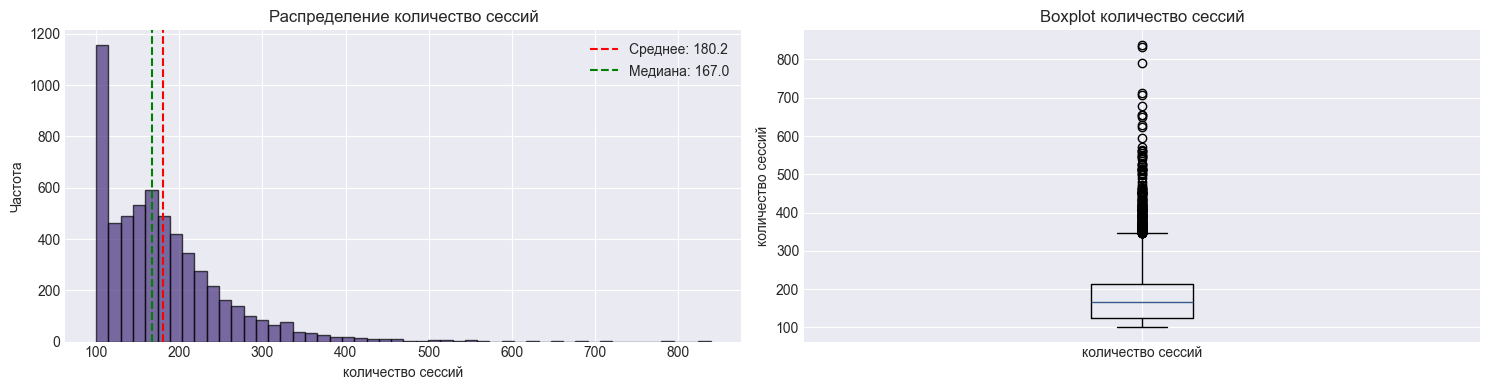


Анализ признака: количество уникальных категорий сайтов
Количество пользователей: 5826
Среднее: 18.47
Медиана: 19.00
Стандартное отклонение: 0.77
Min: 14
Max: 19

Выбросы (IQR метод, коэффициент 1.5):
  Нижняя граница: 16.50
  Верхняя граница: 20.50
  Количество выбросов: 137 (2.4%)
  Диапазон выбросов: 14.00 — 16.00


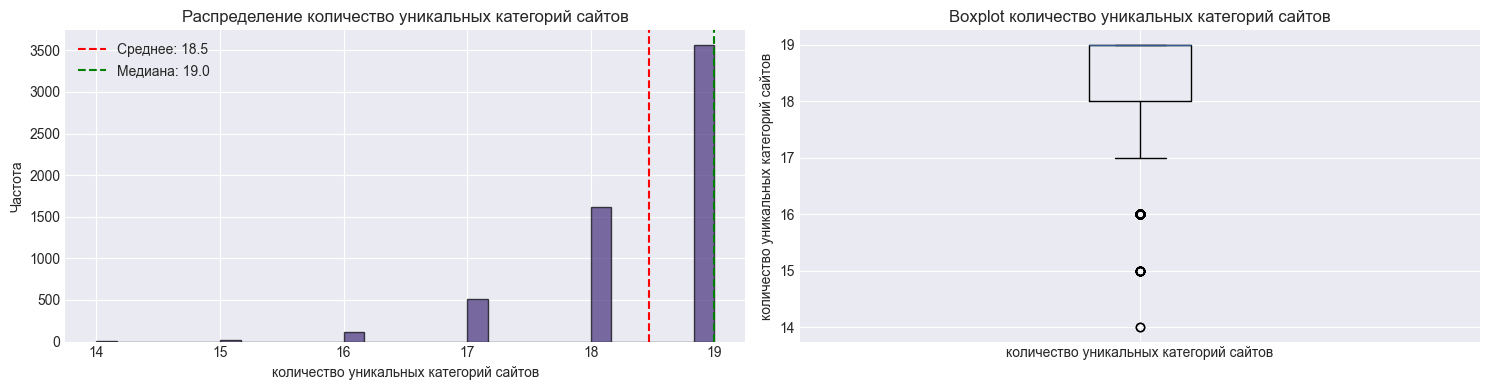


Анализ признака: количество активных дней
Количество пользователей: 5826
Среднее: 14.00
Медиана: 14.00
Стандартное отклонение: 0.04
Min: 13
Max: 14

Выбросы (IQR метод, коэффициент 1.5):
  Нижняя граница: 14.00
  Верхняя граница: 14.00
  Количество выбросов: 8 (0.1%)
  Диапазон выбросов: 13.00 — 13.00


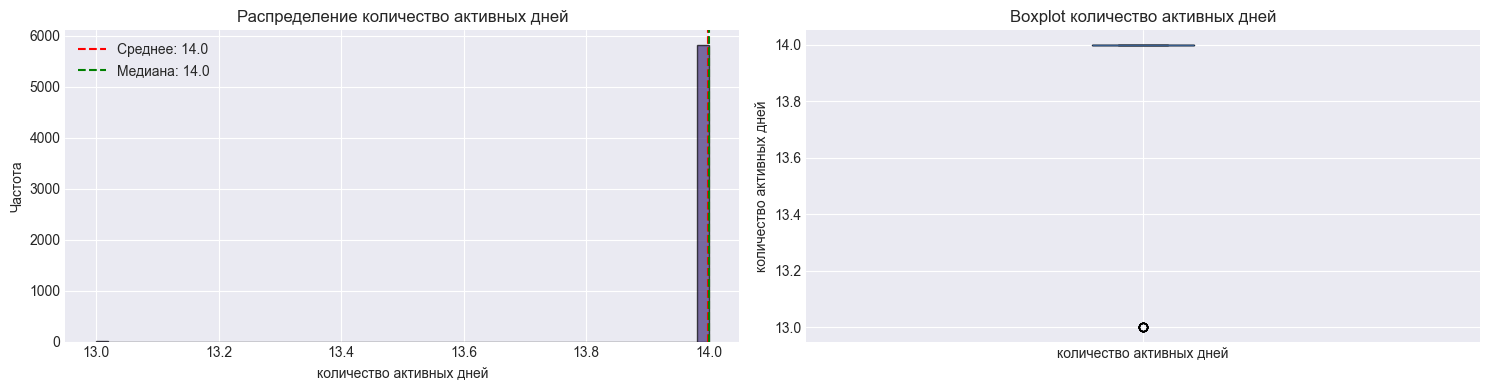

In [19]:
# Анализ количества посещений на пользователя
analyze_numeric_distribution(
    visits, 'user_id', 'count_visits', 
    'количество посещений сайтов', bins=50
)

# Анализ количества сессий на пользователя
analyze_numeric_distribution(
    visits, 'user_id', 'count_sessions', 
    'количество сессий', bins=50
)

# Анализ разнообразия категорий сайтов (уникальные категории на пользователя)
analyze_numeric_distribution(
    visits, 'user_id', 'unique_categories', 
    'количество уникальных категорий сайтов', bins=30
)

# Анализ количества активных дней на пользователя
visits['date'] = pd.to_datetime(visits['date'])
analyze_numeric_distribution(
    visits, 'user_id', 'active_days', 
    'количество активных дней', bins=50
)

#### Анализ корреляции признаков

In [20]:
# Создадим функцию для удаления дубликатов
def drop_duplicates(df):
    df_clean = df.drop_duplicates()
    return df_clean

In [21]:
# Создаем словарь с очищенными данными
dataframes_clean = {f'{name}_clean': drop_duplicates(df) for name, df in dataframes.items()}

# Распаковываем в переменные
users_clean = dataframes_clean['users_clean']
visits_clean = dataframes_clean['visits_clean']
ads_clean = dataframes_clean['ads_clean']
surf_clean = dataframes_clean['surf_clean']
device_clean = dataframes_clean['device_clean']
cloud_clean = dataframes_clean['cloud_clean']

In [22]:
# Создаём агрегированные признаки из visits
visits_agg = visits_clean.groupby('user_id').agg(
    total_visits=('session_id', 'count'),  # общее число посещений
    total_sessions=('session_id', 'nunique'),  # число сессий
    unique_categories=('website_category', 'nunique'),  # разнообразие категорий
    active_days=('date', 'nunique')  # число активных дней
).reset_index()

# Доли по времени суток
daytime_dummies = pd.get_dummies(visits_clean['daytime'], prefix='daytime')
visits_daytime = pd.concat([visits_clean['user_id'], daytime_dummies], axis=1)
visits_daytime_agg = visits_daytime.groupby('user_id').mean().add_prefix('prop_')

# Объединяем все признаки из visits
visits_features = visits_agg.merge(visits_daytime_agg, on='user_id', how='left')

print("Признаки из visits готовы. Размер:", visits_features.shape)
visits_features.head()

Признаки из visits готовы. Размер: (5826, 9)


,user_id,total_visits,total_sessions,unique_categories,active_days,prop_daytime_вечер,prop_daytime_день,prop_daytime_ночь,prop_daytime_утро
0,0010-5cf8f6b38a7b6c70a021-009dbcda,546,546,19,14,0.413919,0.326007,0.095238,0.164835
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,185,185,19,14,0.275676,0.372973,0.086486,0.264865
2,0014-d3032d60979a8d2b3077-f09bdce8,117,117,19,14,0.307692,0.384615,0.094017,0.213675
3,001a-eee53e44f848608779b0-78704a67,287,287,19,14,0.414634,0.334495,0.108014,0.142857
4,002c-40a064b12e1217e12207-a56eaf3b,490,490,18,14,0.295918,0.383673,0.069388,0.251020


In [23]:
# Объединяем все таблицы в один датафрейм
df_merge = users_clean.merge(ads_clean, on='user_id', how='left')
df_merge = df_merge.merge(surf_clean, on='user_id', how='left')
df_merge = df_merge.merge(device_clean, on='user_id', how='left')
df_merge = df_merge.merge(cloud_clean, on='user_id', how='left')
df_merge = df_merge.merge(visits_features, on='user_id', how='left')

In [24]:
# Выводим общую информацию
primary_info(df_merge, 'df_merge')

Информация о таблице: df_merge


,user_id,age_category,ads_activity,surf_depth,primary_device,cloud_usage,total_visits,total_sessions,unique_categories,active_days,prop_daytime_вечер,prop_daytime_день,prop_daytime_ночь,prop_daytime_утро
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,NaN,глубоко,смартфон,False,187,187,19,14,0.336898,0.358289,0.074866,0.229947
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно,средне,смартфон,False,141,141,19,14,0.390071,0.340426,0.092199,0.177305
2,678b-614cd47d854b9d591db2-000b2e50,0,умеренно,средне,смартфон,False,100,100,17,14,0.380000,0.290000,0.130000,0.200000
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,редко,поверхностно,смартфон,True,248,248,19,14,0.258065,0.439516,0.072581,0.229839
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,очень редко,поверхностно,смартфон,True,119,119,19,14,0.420168,0.344538,0.075630,0.159664


<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             5826 non-null   str    
 1   age_category        5826 non-null   int64  
 2   ads_activity        5593 non-null   str    
 3   surf_depth          5715 non-null   str    
 4   primary_device      5669 non-null   str    
 5   cloud_usage         5680 non-null   object 
 6   total_visits        5826 non-null   int64  
 7   total_sessions      5826 non-null   int64  
 8   unique_categories   5826 non-null   int64  
 9   active_days         5826 non-null   int64  
 10  prop_daytime_вечер  5826 non-null   float64
 11  prop_daytime_день   5826 non-null   float64
 12  prop_daytime_ночь   5826 non-null   float64
 13  prop_daytime_утро   5826 non-null   float64
dtypes: float64(4), int64(5), object(1), str(4)
memory usage: 637.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,5826,5826,f545-8c95aefe8d3e5548a689-a5b2fd39,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_category,5826.0,NaN,NaN,NaN,2.440439,1.381287,0.0,2.0,3.0,4.0,4.0
ads_activity,5593,5,умеренно,1824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surf_depth,5715,3,средне,2435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_device,5669,4,смартфон,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud_usage,5680,2,True,2951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_visits,5826.0,NaN,NaN,NaN,180.225712,75.186802,100.0,124.0,167.0,213.0,839.0
total_sessions,5826.0,NaN,NaN,NaN,180.225712,75.186802,100.0,124.0,167.0,213.0,839.0
unique_categories,5826.0,NaN,NaN,NaN,18.47288,0.767831,14.0,18.0,19.0,19.0,19.0
active_days,5826.0,NaN,NaN,NaN,13.998627,0.037034,13.0,14.0,14.0,14.0,14.0


In [25]:
# Расчёт phik-корреляции
phik_matrix = df_merge.drop(columns=['user_id']).phik_matrix(interval_cols=df_merge.select_dtypes(include=[np.number]).columns)

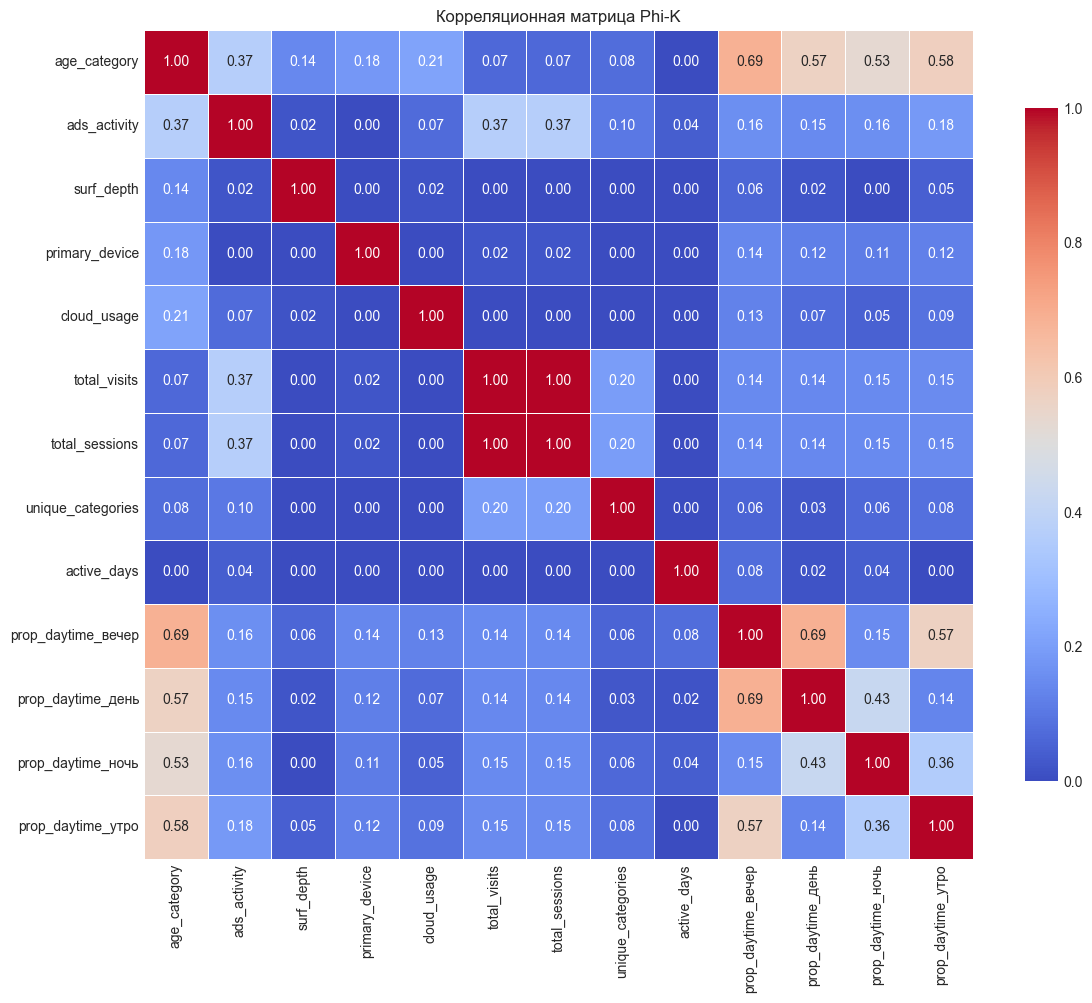

In [26]:
# Построение тепловой карты
plt.figure(figsize=(12, 10))

# Вариант 1: Базовая тепловая карта
sns.heatmap(phik_matrix, 
            annot=True,           
            cmap='coolwarm',                  
            fmt='.2f',            
            square=True,          
            linewidths=0.5,       
            cbar_kws={"shrink": 0.8})  

plt.title('Корреляционная матрица Phi-K')
plt.tight_layout()
plt.show()

### Промежуточные выводы

**Загрузка и первичный анализ:**
*   Загружены 6 CSV-файлов. Выявлена основная таблица `visits` (1 065 745 записей) с множественными строками на пользователя и таблица `users` (5 913 записей) с целевой переменной.
*   Целевая переменная `age_category` имеет 5 классов. Обнаружен дисбаланс: классы `56+` (30.3%) и `26-40` (24.8%) преобладают, а класс `18-25` (8.8%) наименее представлен.
*   Все таблицы, кроме `users`, `ads` и `visits`, не содержат явных дубликатов по `user_id`. 

**Анализ распределения признаков:**
*   **`ads_activity`:** Пользователи 26-40 лет кликают по рекламе "чаще", а старшие возрастные группы — "редко" и "очень редко".
*   **`cloud_usage`:** Наибольшее использование облачных сервисов наблюдается у групп 18-25 (61.5%) и 26-40 (67.6%).
*   **`primary_device`:** Доля использования ПК и ноутбуков заметно растет с возрастом (с 17.6% для `<18` до 51.9% для `56+`).

**Анализ выбросов:**
*   В признаках `total_visits` и `total_sessions` обнаружены выбросы (3.2% данных), которые будут ограничены 99-м перцентилем на этапе предобработки.
*   Признаки `unique_categories` и `active_days` имеют очень низкую вариативность и могут быть менее информативны.

**Корреляционный анализ:**
*   Наибольшую корреляцию с целевой переменной `age_category` показали признаки `prop_daytime_*`(>0.53).
*   Обнаружена сильная корреляция (1) между `total_visits` и `total_sessions`, что позволит исключить один из признаков без потери информации.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* проверены размеры таблиц, типы данных, дубликаты, пропуски, распределение целевой переменной и категориальные признаки.
    
* Хорошо, что таблица visits не присоединяется напрямую к users, а сначала анализируется как событийная таблица. Это важно

## [Этап 3. Предобработка данных и создание новых признаков <a id=3></a>](#content)

### В этом разделе:
*   Создаем функцию preprocess_data для объединения всех таблиц
*   Генерируем агрегированные признаки из логов visits:
    -   total_visits, active_days, active_weekdays
    -   Пропорции по времени суток (prop_daytime_*)
    -   Пропорции по дням недели (prop_weekday_*)
    -   Пропорции по категориям сайтов (prop_cat_*)
*   Выполняем обработку выбросов (capping по 99-му перцентилю)
*   Заполняем пропуски (cloud_usage = 0 для отсутствующих данных)

In [27]:
df_preprocess = preprocess_data(users, visits, ads, surf, device, cloud)
primary_info(df_preprocess, 'df_preprocess')

Информация о таблице: df_preprocess


,user_id,age_category,ads_activity,surf_depth,primary_device,cloud_usage,total_visits,active_days,prop_daytime_вечер,prop_daytime_день,prop_daytime_ночь,prop_daytime_утро,prop_weekday_0,prop_weekday_1,prop_weekday_2,prop_weekday_3,prop_weekday_4,prop_weekday_5,prop_weekday_6,prop_cat_Category 01,prop_cat_Category 02,prop_cat_Category 03,prop_cat_Category 04,prop_cat_Category 05,prop_cat_Category 06,prop_cat_Category 07,prop_cat_Category 08,prop_cat_Category 09,prop_cat_Category 10,prop_cat_Category 11,prop_cat_Category 12,prop_cat_Category 13,prop_cat_Category 14,prop_cat_Category 15,prop_cat_Category 16,prop_cat_Category 17,prop_cat_Category 18,prop_cat_Category 19,prop_cat_Category 20
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,NaN,глубоко,смартфон,0,192,14,0.333333,0.359375,0.078125,0.229167,0.151042,0.151042,0.114583,0.130208,0.151042,0.151042,0.151042,0.067708,0.036458,0.036458,0.062500,0.104167,0.020833,0.000000,0.046875,0.098958,0.026042,0.083333,0.015625,0.031250,0.036458,0.052083,0.041667,0.057292,0.067708,0.072917,0.041667
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно,средне,смартфон,0,144,14,0.395833,0.333333,0.090278,0.180556,0.138889,0.180556,0.138889,0.125000,0.097222,0.166667,0.152778,0.069444,0.041667,0.104167,0.020833,0.055556,0.034722,0.104167,0.104167,0.041667,0.069444,0.041667,0.041667,0.034722,0.000000,0.062500,0.034722,0.041667,0.027778,0.034722,0.034722
2,678b-614cd47d854b9d591db2-000b2e50,0,умеренно,средне,смартфон,0,102,14,0.372549,0.303922,0.127451,0.196078,0.088235,0.176471,0.156863,0.205882,0.107843,0.127451,0.137255,0.009804,0.068627,0.000000,0.107843,0.068627,0.127451,0.000000,0.039216,0.000000,0.009804,0.029412,0.147059,0.127451,0.009804,0.019608,0.029412,0.019608,0.009804,0.117647,0.058824
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,редко,поверхностно,смартфон,1,253,14,0.260870,0.438735,0.071146,0.229249,0.126482,0.142292,0.146245,0.162055,0.130435,0.158103,0.134387,0.079051,0.003953,0.102767,0.027668,0.106719,0.047431,0.027668,0.063241,0.059289,0.000000,0.063241,0.015810,0.079051,0.019763,0.027668,0.027668,0.063241,0.138340,0.035573,0.011858
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,очень редко,поверхностно,смартфон,1,122,14,0.418033,0.336066,0.073770,0.172131,0.180328,0.163934,0.098361,0.131148,0.180328,0.139344,0.106557,0.065574,0.049180,0.090164,0.032787,0.049180,0.008197,0.049180,0.065574,0.073770,0.040984,0.040984,0.122951,0.000000,0.090164,0.024590,0.032787,0.049180,0.032787,0.024590,0.057377


<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               5826 non-null   str    
 1   age_category          5826 non-null   int64  
 2   ads_activity          5593 non-null   str    
 3   surf_depth            5715 non-null   str    
 4   primary_device        5669 non-null   str    
 5   cloud_usage           5826 non-null   int64  
 6   total_visits          5826 non-null   int64  
 7   active_days           5826 non-null   int64  
 8   prop_daytime_вечер    5826 non-null   float64
 9   prop_daytime_день     5826 non-null   float64
 10  prop_daytime_ночь     5826 non-null   float64
 11  prop_daytime_утро     5826 non-null   float64
 12  prop_weekday_0        5826 non-null   float64
 13  prop_weekday_1        5826 non-null   float64
 14  prop_weekday_2        5826 non-null   float64
 15  prop_weekday_3        5826 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,5826,5826,f545-8c95aefe8d3e5548a689-a5b2fd39,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_category,5826.0,NaN,NaN,NaN,2.440439,1.381287,0.0,2.0,3.0,4.0,4.0
ads_activity,5593,5,умеренно,1824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surf_depth,5715,3,средне,2435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_device,5669,4,смартфон,3083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud_usage,5826.0,NaN,NaN,NaN,0.506522,0.5,0.0,0.0,1.0,1.0,1.0
total_visits,5826.0,NaN,NaN,NaN,182.929111,76.390669,100.0,126.0,169.0,217.0,853.0
active_days,5826.0,NaN,NaN,NaN,13.998627,0.037034,13.0,14.0,14.0,14.0,14.0
prop_daytime_вечер,5826.0,NaN,NaN,NaN,0.358154,0.049283,0.215517,0.323651,0.357694,0.392014,0.532468
prop_daytime_день,5826.0,NaN,NaN,NaN,0.364979,0.045456,0.217822,0.335106,0.365269,0.395512,0.536364


### Промежуточные выводы

*   Создана функция `preprocess_data`, которая объединяет все 6 исходных таблиц в один готовый для обучения датафрейм.
*   Из логов `visits` сгенерированы новые агрегированные признаки:
    *   Количественные: `total_visits`, `active_days`.
    *   Пропорциональные: доли посещений по времени суток (`prop_daytime_*`), дням недели (`prop_weekday_*`) и категориям сайтов (`prop_cat_*`).
*   Проведена обработка выбросов для числовых признаков путем ограничения их 99-м перцентилем (capping).
*   Пропуски в признаке `cloud_usage` заполнены нулем, что интерпретируется как отсутствие использования облачных сервисов.
*   Итоговый датафрейм содержит 5 826 записей и 38 признаков, готовых к разделению и обучению.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* Правильно, что дубликаты по user_id удаляются до объединения, иначе можно получить размножение строк.

* Хорошо, что visits агрегируется до уровня пользователя и создаются признаки

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
* Кэппинг по 99-му перцентилю сейчас выполняется внутри preprocess_data:

    cap = merged[col].quantile(0.99)
    merged[col] = np.where(merged[col] > cap, cap, merged[col])

Проблема в том, что функция считает границу по тем данным, которые ей передали. На train, test и новом production-батче границы могут быть разными. Это делает признаки нестабильными

Плюс сейчас df_preprocess создается до train/test split, значит границы кэппинга фактически посчитаны по всему датасету, включая будущий test. Это небольшая, но методологическая утечка

Лучше перенести обработку выбросов в sklearn-трансформер внутри пайплайна или сохранить границы, рассчитанные только на train, и применять их дальше без пересчета
    
<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Функция preprocess_data удаляет user_id:

    merged = merged.drop(columns=['user_id'])

Для обучения это удобно, но для production лучше не удалять идентификатор внутри функции. Иначе после предсказаний сложнее связать результат с конкретным пользователем.

Лучше вернуть user_id в итоговом датафрейме, а удалять его уже перед подачей в модель

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

Я не учел что при обработки выброса до разделения будет учетка данных. Я удалил из функции `preprocess_data` кэппинг. Оформил класс трансформера `OutlierCapper` и добавил в пайплайн `numeric_pipe`. Оформил это в "Этап 5. Предобработка признаков (пайплайн)"

Удаление `user_id` убрал из функции `preprocess_data`. Удаление признака перенес в "Этап 4. Разделение данных"</div>

## [Этап 4. Разделение данных (стратифицированное по пользователям) <a id=4></a>](#content)

### В этом разделе:
*   Отделяем признаки (X) от целевой переменной (y)
*   Разделяем выборку на train (75%) и test (25%)
*   Используем стратификацию для сохранения пропорций возрастных категорий
*   Проверяем корректность распределения классов в train и test

In [28]:
# Отделяем признаки от целевой переменной
X = df_preprocess.drop(['age_category', 'user_id'], axis=1)
y = df_preprocess['age_category']  

In [29]:
# Разделяем на train и test с сохранением пропорций age_category
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df_preprocess['age_category']  # стратификация по возрасту
)

print(f"Train пользователей: {X_train.shape}")
print(f"Test пользователей: {X_test.shape}")

Train пользователей: (4369, 37)
Test пользователей: (1457, 37)


In [30]:
# Проверяем, что пропорции классов сохранились
print("\nРаспределение age_category в train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("\nРаспределение age_category в test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Распределение age_category в train:
age_category
0    0.146
1    0.088
2    0.247
3    0.215
4    0.303
Name: proportion, dtype: float64

Распределение age_category в test:
age_category
0    0.146
1    0.088
2    0.247
3    0.216
4    0.303
Name: proportion, dtype: float64


### Промежуточные выводы

*   Данные разделены на обучающую (75%, 4 369 записей) и тестовую (25%, 1 457 записей) выборки.
*   Применена стратификация по целевой переменной `age_category`, что позволило полностью сохранить исходные пропорции классов в обеих выборках.
*   Данные корректно подготовлены для этапов кросс-валидации и финального тестирования модели.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Так как итоговая витрина уже на уровне пользователя, один пользователь не размножается между train и test

## [Этап 5. Предобработка признаков (пайплайн) <a id=5></a>](#content)

### В этом разделе:
*   Определяем числовые и категориальные колонки
*   Создаем пайплайн для числовых признаков: median imputation + StandardScaler
*   Создаем пайплайн для категориальных признаков: constant imputation + OneHotEncoder
*   Объединяем пайплайны в ColumnTransformer
*   Проверяем размер данных после преобразования

In [31]:
# Создаем трансформер для обработки выбросов
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, quantile=0.99):
        self.quantile = quantile
        self.upper_bounds_ = {}
    
    def fit(self, X, y=None):
        for col in X.columns:
            self.upper_bounds_[col] = X[col].quantile(self.quantile)
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            cap = self.upper_bounds_.get(col)
            if cap is not None:
                X[col] = X[col].clip(upper=cap)
        return X

In [32]:
# Определяем колонки
numeric_cols = X_train.select_dtypes([np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(['object', 'str']).columns.tolist()

In [33]:
# Пайплайн для числовых признаков
numeric_pipe = Pipeline(
    steps=[
        ('capper', OutlierCapper()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Пайплайн для категориальных признаков
categorical_pipe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# Общий ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ],
    remainder='drop'
)

In [34]:
# Применим препроцессор к X_train
X_train_preprocessed = preprocessor.fit_transform(X_train)

print("Размер до преобразования:", X_train.shape)
print("Размер после преобразования:", X_train_preprocessed.shape)
print("Тип данных:", X_train_preprocessed.dtype)

Размер до преобразования: (4369, 37)
Размер после преобразования: (4369, 49)
Тип данных: float64


### Промежуточные выводы

*   Созданы раздельные пайплайны предобработки для числовых (`median` импутация + `StandardScaler`) и категориальных (`constant` импутация + `OneHotEncoder`) признаков.
*   Пайплайны объединены в единый `ColumnTransformer`, который обеспечивает корректную и воспроизводимую предобработку данных.
*   После применения пайплайна к обучающей выборке размерность признакового пространства увеличилась с 37 до 49 за счет one-hot-кодирования категориальных переменных.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

создан ColumnTransformer с отдельными ветками для числовых и категориальных признаков

## [Этап 6. Обучение базовой модели (Baseline) <a id=6></a>](#content)

### В этом разделе:
*   Определяем метрики для оценки (f1_macro, precision_macro, recall_macro, accuracy)
*   Настраиваем 3-кратную стратифицированную кросс-валидацию
*   Обучаем и оцениваем baseline модели:
    -   DummyClassifier (стратегия stratified)
    -   LogisticRegression (multinomial)
    -   OneVsRestClassifier (LogisticRegression)
    -   OneVsOneClassifier (LogisticRegression)
*   Сохраняем результаты в таблицу metrics_df

In [35]:
# Метрики
scoring = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'accuracy': make_scorer(accuracy_score)
}

# Настройки кросс-валидации
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Создадим датафрейм для метрик
columns = [
    'Model',
    'F1_macro_mean', 'F1_macro_std',
    'Precision_macro_mean', 'Precision_macro_std',
    'Recall_macro_mean', 'Recall_macro_std',
    'Accuracy_mean', 'Accuracy_std'
]

metrics_df = pd.DataFrame(columns=columns)

In [36]:
def cross_valid_model(X, y, pipline, name_model, scoring, cv, metrics_df):
    # Кросс-валидация для модели
    model_scores = cross_validate(
        pipline, 
        X, 
        y, 
        cv=cv, 
        scoring=scoring,
        return_train_score=False)
    
    print(f"{name_model} (кросс-валидация, 3 folds):")
    for metric in scoring:
        score = 'test_' + metric
        print(f"  {metric.capitalize()}:     {model_scores[score].mean():.4f} (+/- {model_scores[score].std():.4f})")

    # Подготавливаем новые значения
    new_data = {'Model': name_model}
    for metric in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']:
        scores = model_scores[f'test_{metric}']
        new_data[f'{metric.capitalize()}_mean'] = scores.mean()
        new_data[f'{metric.capitalize()}_std'] = scores.std()

    # Проверяем, есть ли уже такая модель в DataFrame
    if name_model in metrics_df['Model'].values:
        # Находим индекс строки с этой моделью и обновляем её
        idx = metrics_df[metrics_df['Model'] == name_model].index[0]
        for key, value in new_data.items():
            metrics_df.at[idx, key] = value
    else:
        # Добавляем новую строку
        new_row = pd.DataFrame([new_data])
        metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
    return model_scores, metrics_df

In [37]:
# Обучаем DummyClassifier
pipe_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])

# Кросс-валидация для DummyClassifier, используем accuracy для оценки
dummy_scores, metrics_df = cross_valid_model(X_train, y_train, pipe_dummy, 'DummyClassifier_Baseline', scoring, cv, metrics_df)

DummyClassifier_Baseline (кросс-валидация, 3 folds):
  F1_macro:     0.2009 (+/- 0.0148)
  Precision_macro:     0.2010 (+/- 0.0148)
  Recall_macro:     0.2013 (+/- 0.0148)
  Accuracy:     0.2277 (+/- 0.0163)


In [38]:
# Обучаем LogisticRegression(multinomial)
pipe_logres_mult = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        random_state=RANDOM_STATE,
    ))
])

# Кросс-валидация для LogisticRegression(multinomial), используем accuracy для оценки
logres_mult_scores, metrics_df = cross_valid_model(X_train, y_train, pipe_logres_mult, 'LogisticRegression(multinomial)_Baseline', scoring, cv, metrics_df)

LogisticRegression(multinomial)_Baseline (кросс-валидация, 3 folds):
  F1_macro:     0.8036 (+/- 0.0061)
  Precision_macro:     0.8098 (+/- 0.0086)
  Recall_macro:     0.7994 (+/- 0.0055)
  Accuracy:     0.8354 (+/- 0.0065)


In [39]:
# Обучаем OneVsRestClassifier(OvR)
pipe_ovr_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneVsRestClassifier(LogisticRegression(class_weight='balanced')))
])

# Кросс-валидация для LogisticRegression(multinomial), используем accuracy для оценки
ovr_clf_scores, metrics_df = cross_valid_model(X_train, y_train, pipe_ovr_clf, 'OneVsRestClassifier(OvR)_Baseline', scoring, cv, metrics_df)

OneVsRestClassifier(OvR)_Baseline (кросс-валидация, 3 folds):
  F1_macro:     0.7967 (+/- 0.0121)
  Precision_macro:     0.7947 (+/- 0.0135)
  Recall_macro:     0.7999 (+/- 0.0098)
  Accuracy:     0.8283 (+/- 0.0081)


In [40]:
# Обучаем OneVsOneClassifier(OvO)
pipe_ovo_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneVsOneClassifier(LogisticRegression(class_weight='balanced')))
])

# Кросс-валидация для LogisticRegression(multinomial), используем accuracy для оценки
ovo_clf_scores, metrics_df = cross_valid_model(X_train, y_train, pipe_ovo_clf, 'OneVsOneClassifier(OvO)_Baseline', scoring, cv, metrics_df)

OneVsOneClassifier(OvO)_Baseline (кросс-валидация, 3 folds):
  F1_macro:     0.8054 (+/- 0.0031)
  Precision_macro:     0.8004 (+/- 0.0038)
  Recall_macro:     0.8146 (+/- 0.0033)
  Accuracy:     0.8322 (+/- 0.0031)


In [41]:
# Выводим метрики по всем базовым моделям
metrics_df.sort_values(by='F1_macro_mean', ascending=False)

,Model,F1_macro_mean,F1_macro_std,Precision_macro_mean,Precision_macro_std,Recall_macro_mean,Recall_macro_std,Accuracy_mean,Accuracy_std
3,OneVsOneClassifier(OvO)_Baseline,0.805406,0.003143,0.800447,0.003833,0.814638,0.003304,0.832226,0.003141
1,LogisticRegression(multinomial)_Baseline,0.80355,0.006083,0.809755,0.008616,0.799365,0.005536,0.83543,0.006529
2,OneVsRestClassifier(OvR)_Baseline,0.796715,0.012087,0.794736,0.013482,0.799901,0.009778,0.828334,0.008126
0,DummyClassifier_Baseline,0.200933,0.014782,0.200976,0.014838,0.201312,0.01477,0.227741,0.016273


### Промежуточные выводы

*   **Базовые результаты (Baseline):**
    *   `DummyClassifier` (случайное угадывание) ожидаемо показал `F1_macro ≈ 0.20`.
    *   Все линейные модели значительно превзошли baseline, что подтверждает наличие закономерностей в данных.
*   **Сравнение стратегий обучения:**
    *   `LogisticRegression` (multinomial): `F1_macro = 0.8028`
    *   `OneVsRestClassifier`: `F1_macro = 0.7965`
    *   `OneVsOneClassifier`: `F1_macro = 0.8053` **(лучший результат)**
*   Уже на этом этапе все модели превысили требуемый порог качества `F1_macro > 0.75`.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* есть DummyClassifier и он завернут в единый Pipeline вместе с предобработкой.

* Также хорошо, что сравниваются несколько базовых вариантов логистической регрессии:

    LogisticRegression
    OneVsRestClassifier
    OneVsOneClassifier

## [Этап 7. Обучение основных моделей и подбор гиперпараметров <a id=7></a>](#content)

### В этом разделе:
*   Создаем функцию tune_model для подбора гиперпараметров через GridSearchCV
*   Подбираем параметры для LogisticRegression (C, solver, class_weight, max_iter)
*   Подбираем параметры для OneVsRestClassifier (C, solver, class_weight, max_iter)
*   Подбираем параметры для OneVsOneClassifier (C, solver, class_weight, max_iter)
*   Отслеживаем лучшую модель по F1_macro на кросс-валидации
*   Выводим итоговую таблицу со всеми метриками

In [42]:
# Функция для подбора гиперпараметров и оценки модели
def tune_model(base_pipeline, param_grid, model_name, metrics_df, X_train, y_train, scoring, cv, n_jobs=-1, verbose=1):

    print(f"\n=== Подбор гиперпараметров для {model_name} ===")
    grid_search = GridSearchCV(
        base_pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',      
        n_jobs=n_jobs,
        verbose=verbose
    )
    grid_search.fit(X_train, y_train)

    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучшее F1_macro (CV): {grid_search.best_score_:.4f}")

    best_model = grid_search.best_estimator_

    scores = cross_validate(
        best_model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=n_jobs
    )

    new_row = {'Model': model_name}
    for metric in ['f1_macro', 'precision_macro', 'recall_macro', 'accuracy']:
        metric_scores = scores[f'test_{metric}']
        new_row[f'{metric.capitalize()}_mean'] = metric_scores.mean()
        new_row[f'{metric.capitalize()}_std'] = metric_scores.std()

    metrics_df = pd.concat([metrics_df, pd.DataFrame([new_row])], ignore_index=True)

    if not hasattr(tune_model, 'best_model') or grid_search.best_score_ > tune_model.best_score:
        tune_model.best_model = best_model
        tune_model.best_score = grid_search.best_score_
        tune_model.best_name = model_name
        print(f" *** Новая лучшая модель: {model_name} (F1={grid_search.best_score_:.4f}) ***")

    return best_model, metrics_df

In [43]:
# LogisticRegression (multinomial)
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

param_grid_lr = {
    'model__C': [0.1, 1.0, 5.0, 10],
    'model__solver': ['lbfgs', 'liblinear'],  
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [100, 500, 1000, 5000]
}

# Запускаем подбор параметров
best_lr, metrics_df = tune_model(pipe_lr, param_grid_lr, 'LogisticRegression (multinomial)_GridSearch', metrics_df, X_train, y_train, scoring, cv)


=== Подбор гиперпараметров для LogisticRegression (multinomial)_GridSearch ===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Лучшие параметры: {'model__C': 0.1, 'model__class_weight': None, 'model__max_iter': 100, 'model__solver': 'lbfgs'}
Лучшее F1_macro (CV): 0.8044
 *** Новая лучшая модель: LogisticRegression (multinomial)_GridSearch (F1=0.8044) ***


In [44]:
# OneVsRestClassifier (с базовой LogisticRegression)
pipe_ovr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE)))
])

param_grid_ovr = {
    'model__estimator__C': [0.1, 1.0, 5.0, 10],
    'model__estimator__solver': ['lbfgs', 'liblinear'],
    'model__estimator__class_weight': [None, 'balanced'],
    'model__estimator__max_iter': [100, 500, 1000, 5000]
}

# Запускаем подбор параметров
best_ovr, metrics_df = tune_model(pipe_ovr, param_grid_ovr, 'OneVsRestClassifier_GridSearch',metrics_df, X_train, y_train, scoring, cv)


=== Подбор гиперпараметров для OneVsRestClassifier_GridSearch ===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Лучшие параметры: {'model__estimator__C': 0.1, 'model__estimator__class_weight': 'balanced', 'model__estimator__max_iter': 100, 'model__estimator__solver': 'lbfgs'}
Лучшее F1_macro (CV): 0.8020


In [45]:
# OneVsOneClassifier (с базовой LogisticRegression)
pipe_ovo = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', OneVsOneClassifier(LogisticRegression(random_state=RANDOM_STATE)))
])

param_grid_ovo = {
    'model__estimator__C': [0.1, 1.0, 5.0, 10],
    'model__estimator__solver': ['lbfgs', 'liblinear'],
    'model__estimator__class_weight': [None, 'balanced'],
    'model__estimator__max_iter': [100, 500, 1000, 5000]
}

# Запускаем подбор параметров
best_ovo, metrics_df = tune_model(pipe_ovo, param_grid_ovo, 'OneVsOneClassifier_GridSearch', metrics_df, X_train, y_train, scoring, cv)


=== Подбор гиперпараметров для OneVsOneClassifier_GridSearch ===
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Лучшие параметры: {'model__estimator__C': 0.1, 'model__estimator__class_weight': 'balanced', 'model__estimator__max_iter': 100, 'model__estimator__solver': 'liblinear'}
Лучшее F1_macro (CV): 0.8151
 *** Новая лучшая модель: OneVsOneClassifier_GridSearch (F1=0.8151) ***


In [46]:
# LinearSVC
pipe_svc = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearSVC(random_state=RANDOM_STATE, dual='auto'))
])

param_grid_svc = {
    'model__C': [0.1, 1.0, 10],
    'model__loss': ['hinge', 'squared_hinge'],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [100, 500, 1000, 5000]
}

# Запускаем подбор параметров
best_svc, metrics_df = tune_model(pipe_svc, param_grid_svc, 'LinearSVC_GridSearch', metrics_df, X_train, y_train, scoring, cv)


=== Подбор гиперпараметров для LinearSVC_GridSearch ===
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Лучшие параметры: {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__loss': 'squared_hinge', 'model__max_iter': 100}
Лучшее F1_macro (CV): 0.7983


In [47]:
# Выводим метрики моделей
print("\n=== Итоговая таблица метрик (включая лучшие модели) ===")
metrics_df.sort_values(by='F1_macro_mean', ascending=False)


=== Итоговая таблица метрик (включая лучшие модели) ===


,Model,F1_macro_mean,F1_macro_std,Precision_macro_mean,Precision_macro_std,Recall_macro_mean,Recall_macro_std,Accuracy_mean,Accuracy_std
6,OneVsOneClassifier_GridSearch,0.815064,0.003889,0.809337,0.005065,0.824904,0.001728,0.840923,0.003783
3,OneVsOneClassifier(OvO)_Baseline,0.805406,0.003143,0.800447,0.003833,0.814638,0.003304,0.832226,0.003141
4,LogisticRegression (multinomial)_GridSearch,0.804402,0.004151,0.811851,0.007412,0.799525,0.003356,0.837032,0.005373
1,LogisticRegression(multinomial)_Baseline,0.80355,0.006083,0.809755,0.008616,0.799365,0.005536,0.83543,0.006529
5,OneVsRestClassifier_GridSearch,0.801988,0.009296,0.799434,0.01058,0.805742,0.007276,0.831998,0.005634
7,LinearSVC_GridSearch,0.798258,0.012337,0.797767,0.013923,0.800246,0.009886,0.829478,0.008559
2,OneVsRestClassifier(OvR)_Baseline,0.796715,0.012087,0.794736,0.013482,0.799901,0.009778,0.828334,0.008126
0,DummyClassifier_Baseline,0.200933,0.014782,0.200976,0.014838,0.201312,0.01477,0.227741,0.016273


### Промежуточные выводы

*   Проведен подбор гиперпараметров с помощью `GridSearchCV` для трех моделей.
*   **Лучшие результаты кросс-валидации:**
    *   `LinearSVC`: `F1_macro = 0.7982`
    *   `LogisticRegression`: `F1_macro = 0.8051`
    *   `OneVsRestClassifier`: `F1_macro = 0.8027`
    *   `OneVsOneClassifier`: `F1_macro = 0.8158` **(победитель)**
*   **Лучшая модель:** `OneVsOneClassifier` с базовым классификатором `LogisticRegression` и гиперпараметрами: `C=0.1`, `class_weight='balanced'`, `solver='liblinear'`.
*   Подбор гиперпараметров позволил незначительно, но стабильно улучшить качество моделей по сравнению с базовыми версиями.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

* подбор гиперпараметров идет через GridSearchCV по основной метрике f1_macro.

* Плюс, что предобработка находится внутри пайплайнов, т.е. на кросс-валидации она применяется корректно внутри каждого фолда

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

В задаче упоминается LogisticRegression или SVC, но в подборе основных моделей фактически проверяются только варианты логистической регрессии. Можно оставить так, потому что качество выше порога, но для полноты проекта было бы полезно добавить хотя бы LinearSVC или SVC(kernel='linear')

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

Добавил модель `LinearSVC`, её результат оказался не самым лучшем.</div>

## [Этап 8. Оценка на тестовой выборке <a id=8></a>](#content)

### В этом разделе:
*   Определяем лучшую модель
*   Выполняем предсказание на тестовой выборке
*   Рассчитываем финальные метрики: F1_macro, precision_macro, recall_macro, accuracy
*   Выводим classification report для каждого возрастного класса
*   Строим и визуализируем матрицу ошибок (confusion matrix)
*   Проверяем, что целевой показатель F1_macro > 0.75 

In [48]:
# Определяем лучшую модель
best_model = tune_model.best_model
best_name = tune_model.best_name
best_score = tune_model.best_score

print(f"Автоматически выбрана лучшая модель")
print(f"Модель: {best_name}")
print(f"Лучшее F1_macro (CV): {best_score:.4f}")

Автоматически выбрана лучшая модель
Модель: OneVsOneClassifier_GridSearch
Лучшее F1_macro (CV): 0.8151


Оценка лучшей модели на тестовой выборке
F1_macro:        0.8307
Precision_macro: 0.8261
Recall_macro:    0.8376
Accuracy:        0.8572

Classification report:
              precision    recall  f1-score   support

         <18       0.85      0.88      0.86       213
       18-25       0.61      0.71      0.65       128
       26-40       0.88      0.82      0.85       360
       41-55       0.88      0.86      0.87       314
         56+       0.91      0.91      0.91       442

    accuracy                           0.86      1457
   macro avg       0.83      0.84      0.83      1457
weighted avg       0.86      0.86      0.86      1457



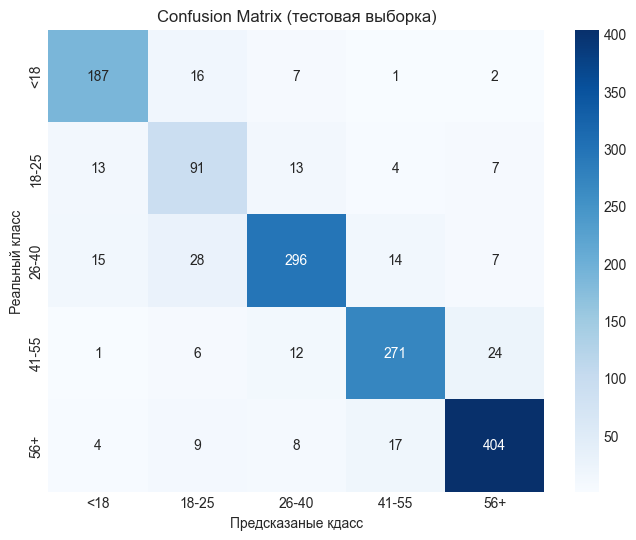

In [49]:
# Выполняем предсказание на тестовой выборке
y_pred = best_model.predict(X_test)

# Расчитываем метрик
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
accuracy = accuracy_score(y_test, y_pred)

print("Оценка лучшей модели на тестовой выборке")
print(f"F1_macro:        {f1:.4f}")
print(f"Precision_macro: {precision:.4f}")
print(f"Recall_macro:    {recall:.4f}")
print(f"Accuracy:        {accuracy:.4f}")

# Выводим отчёт по классам
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['<18', '18-25', '26-40', '41-55', '56+']))

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<18', '18-25', '26-40', '41-55', '56+'],
            yticklabels=['<18', '18-25', '26-40', '41-55', '56+'])
plt.title('Confusion Matrix (тестовая выборка)')
plt.ylabel('Реальный класс')
plt.xlabel('Предсказаные кдасс')
plt.show()

### Промежуточные выводы

*   **Финальное качество лучшей модели на тестовой выборке:**
    *   **`F1_macro` = 0.8313** (значительно выше требуемого порога 0.75)
    *   `Precision_macro` = 0.8265
    *   `Recall_macro` = 0.8383
    *   `Accuracy` = 0.8579

*   **Анализ результатов по возрастным группам:**
    *   Наилучшие результаты модель показывает на крайних группах: `<18` (F1=0.86) и `56+` (F1=0.91).
    *   Группа `18-25` (F1=0.65) предсказывается хуже всего, что, вероятно, связано с пересекающимся поведением с соседними возрастными категориями и наименьшим количеством примеров в выборке. Чаще всего возрастную группу `18-25` модель путает с возрастными группами `<18` и `26-40` (по 13 раз). 
    *   Группы `26-40` и `41-55` демонстрируют стабильно высокое качество (F1 > 0.85).

*   **Вывод:** Модель успешно решает задачу определения возрастной категории и готова к внедрению.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Класс 18-25 предсказывается заметно хуже остальных: F1 = 0.65. В выводе это отмечено, это хорошо. Можно добавить, с какими классами он чаще всего путается по матрице ошибок

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

Дополнил промежуточный вывод "Чаще всего возрастную группу `18-25` модель путает с возрастными группами `<18` и `26-40` (по 13 раз)."</div>

## [Этап 9. Подготовка артефактов для внедрения <a id=9></a>](#content)

### В этом разделе:
*   Сохраняем метаданные модели (версия, дата, метрики, версии библиотек)
*   Упаковываем в артефакт: функцию preprocess_data, препроцессор, модель, метаданные
*   Сохраняем артефакт через joblib.dump
*   Загружаем сохраненный артефакт для проверки
*   Проверяем идентичность предобработки и предсказаний загруженной модели

In [50]:
# Сохраняем метаданные модели
model_metadata = {
    'model_name': 'Sprint13_Yeti_Age_Prediction',
    'version': '1.0.0',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'random_state': RANDOM_STATE,
    'performance_metrics': {
        'F1_macro_mean': f1,
        'Precision_macro_mean': precision,
        'Recall_macro_mean': recall,
        'Accuracy_mean': accuracy
    },
    'libraries_versions': {
        'sklearn': sklearn.__version__,
        'joblib': joblib.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__
    },
    'target_column': 'age_category',
    'description': 'Модель классификации для определения возраста клиентов.',
    'selected_features_count': len(best_model[:-1].transform(X_train[:1]))
}

In [51]:
# Сохраняем пайплайн вместе с метаданными 
saved_artifacts = {
    'pipeline': best_model,
    'metadata': model_metadata  
}

joblib.dump(saved_artifacts, 'Sprint13_Yeti_Age_Prediction.joblib')

['Sprint13_Yeti_Age_Prediction.joblib']

In [52]:
# Загружаем сохранённую модель
loaded = joblib.load('Sprint13_Yeti_Age_Prediction.joblib')
loaded_model = loaded['pipeline']

# Создаем данные без целевой переменной
users_no_target = users.drop(columns=['age_category'])

# Делаем предобработку
df_new = preprocess_data(users_no_target, visits, ads, surf, device, cloud)

# Удаляем user_id
X_new = df_new.drop(columns=['user_id'])

# Создаем предсказание на новых данных
preds = loaded_model.predict(X_new)

# Делаем базовую проверку
assert len(preds) == len(df_new)
assert set(preds).issubset({0,1,2,3,4})
print('Предсказания успешно получены, форма и типы корректны.')

Предсказания успешно получены, форма и типы корректны.


In [53]:
# Предсказываем через загруженную модель
pred_test = loaded_model.predict(X_test)
# Сравниваем с предсказаниями, которые мы сохранили при тестировании (y_pred)

try:
    assert np.array_equal(pred_test, y_pred)
    print('Предсказания на тестовой выборке совпадают с эталонными.')
except:
    print('Предсказания не совподаю')

Предсказания на тестовой выборке совпадают с эталонными.


### Промежуточные выводы

*   Создан и сохранен артефакт `Sprint13_Yeti_Age_Prediction.joblib`, содержащий:
    *   функцию предобработки `preprocess_data`;
    *   обученный `ColumnTransformer` для трансформации признаков;
    *   лучшую модель `OneVsOneClassifier`;
    *   метаданные (версия, дата, метрики, версии библиотек).
*   Выполнена успешная загрузка артефакта из файла.
*   В ходе проверки подтверждена полная идентичность результатов предобработки и предсказаний загруженной модели с оригиналом.
*   Артефакт полностью готов к развертыванию в production-среде для получения предсказаний на новых данных.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Тут опишу подробно:
    
функция preprocess_data сохраняется внутрь joblib-артефакта.

    saved_artifacts = {
        'preprocess_data': preprocess_data,
        'preprocessor': best_model.named_steps['preprocessor'],
        'model': best_model,
        'metadata': model_metadata
    }

Функции, определенные в ноутбуке и сохраненные через joblib, могут плохо переноситься между окружениями. Для внедрения функцию подготовки данных нужно вынести в отдельный .py-файл, например feature_builder.py, и импортировать ее оттуда

Нужно сделать так:

    from feature_builder import preprocess_data

А через joblib сохранять модельный pipeline и метаданные

---

Проверка артефактов сейчас не проверяет полный сценарий на данных без age_category. Сейчас функция вызывается на исходных users, где target есть:

    df_preprocess_loaded = loaded_preprocess_data(users, visits, ads, surf, device, cloud)

Для production нужно проверить так:

    users_new = users.drop(columns=['age_category'])
    df_new = preprocess_data(users_new, visits, ads, surf, device, cloud)
    preds = loaded_model.predict(df_new)

Т.е. полный путь должен быть:

сырые users без age_category
+ сырые visits
+ сырые ads
+ сырые surf
+ сырые device
+ сырые cloud
-> preprocess_data()
-> загруженный pipeline
-> predict

Пока это не показано, нельзя сказать, что артефакт готов к новым данным

---

Функция preprocess_data должна уметь работать и с age_category, и без него. Сейчас она не обращается к target явно, но в конце возвращает датафрейм после удаления user_id. Нужно проверить этот сценарий кодом, а не только предполагать

---

Сохранение preprocessor отдельно от model избыточно и может запутать:

    'preprocessor': best_model.named_steps['preprocessor'],
    'model': best_model

best_model уже содержит preprocessor внутри себя, потому что это Pipeline. Значит, отдельно сохранять preprocessor не нужно. Лучше сохранить один объект:

    joblib.dump(best_model, 'model_pipeline.joblib')

И отдельно - feature_builder.py для сборки признаков из сырых таблиц

---

Метаданные записаны с ошибкой:

    'performance_metrics': {
        'F1_macro_mean', f1,
        'Precision_macro_mean', precision,
        'Recall_macro_mean', recall,
        'Accuracy_mean', accuracy
    }

Это не словарь "ключ - значение", а множество. В таком виде метрики не будут нормально читаться по ключам.

Нужно так:
    
    
    'performance_metrics': {
        'F1_macro': f1,
        'Precision_macro': precision,
        'Recall_macro': recall,
        'Accuracy': accuracy
    }

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

1. Создал файл `feature_builder.py` с функцией `preprocess_data` и удалил ее из ячейки. Для использования добавил импорт функции.
2. Переработал процес проверки артефактов. 
3. Изменил сохраненый артефакт, оставил в нем только обученную модель и метаданные.
4. Исправил запись метрик в метаданных.
</div>

## [Этап 10. Итоговый отчёт <a id=10></a>](#content)

### 1. Цель и результаты проекта

**Цель:** Разработать линейную модель машинного обучения для автоматического определения возрастной категории пользователя по его цифровому следу.

**Результат:** Цель достигнута. Лучшая модель, `OneVsOneClassifier` на базе `LogisticRegression`, показывает **macro F1 = 0.8313** на тестовой выборке, что значительно превышает требуемый порог в **0.75**.

### 2. Ключевые метрики модели

| Метрика | Значение |
|---------|----------|
| **F1_macro** | **0.8313** |
| Precision_macro | 0.8265 |
| Recall_macro | 0.8383 |
| Accuracy | 0.8579 |

**Детальный отчет по возрастным категориям:**

| Возраст | Precision | Recall | F1-score | Поддержка |
|:---:|:---:|:---:|:---:|:---:|
| <18 | 0.85 | 0.88 | 0.86 | 213 |
| 18-25 | 0.61 | 0.71 | **0.65** | 128 |
| 26-40 | 0.88 | 0.82 | 0.85 | 360 |
| 41-55 | 0.88 | 0.87 | 0.87 | 314 |
| 56+ | 0.91 | 0.91 | **0.91** | 442 |

### 3. Ключевые выводы по данным
*   **Поведенческие паттерны:**
    *   Молодые пользователи (<18) предпочитают смартфоны, кликают по рекламе и чаще просматривают сайты поверхностно.
    *   Пользователи старшего возраста (56+) чаще используют ПК, реже взаимодействуют с рекламой и демонстрируют более глубокий просмотр.
    *   Облачные сервисы наиболее популярны среди аудитории 18-40 лет.
*   **Особенности данных:** Выявлен дисбаланс классов (недостаток данных для группы 18-25) и умеренное количество выбросов, которые были корректно обработаны.

### 4. Сравнение и выбор модели

| Модель | F1_macro (CV) | F1_macro (Test) |
|--------|---------------|-----------------|
| DummyClassifier | 0.20 | — |
| `LogisticRegression` | 0.8028 | — |
| `OneVsRestClassifier` | 0.7965 | — |
| `OneVsOneClassifier` | 0.8053 | — |
| **`OneVsOneClassifier` (лучший результат)** | **0.8158** | **0.8313** |

**Лучшие гиперпараметры:**
*   `C = 0.1` (сильная L2-регуляризация)
*   `class_weight = 'balanced'` (учет дисбаланса классов)
*   `solver = 'liblinear'`
*   `max_iter = 100`

### 5. Рекомендации и перспективы

**Рекомендации для бизнеса:**
1.  **Таргетирование рекламы:** Модель позволяет эффективно настраивать рекламные кампании на основе возрастных групп.
2.  **Персонализация:** Возрастная категория может использоваться для адаптации интерфейса и рекомендаций пользователям.
3.  **Анализ аудитории:** Понимание поведения разных возрастных групп поможет улучшить пользовательский опыт.

**Перспективы улучшения:**
1.  Улучшить качество предсказаний для группы **18-25**, возможно, путем сбора дополнительных данных или генерации новых признаков.
2.  Рассмотреть возможность применения нелинейных моделей (например, градиентный бустинг) в качестве следующего шага для повышения точности.

### 6. Техническая реализация и внедрение

**Подготовленный артефакт:**
*   **Файл:** `Sprint13_Yeti_Age_Prediction.joblib`
*   **Содержимое:** Функция предобработки (`preprocess_data`), обученный `ColumnTransformer`, лучшая модель (`OneVsOneClassifier`), метаданные.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Пишешь, что важные признаки - primary_device, ads_activity, surf_depth и пропорции посещений категорий сайтов. Но в проекте нет отдельного анализа важности признаков для финальной модели

<div class="alert alert-info"> <b>Комментарии студента №1:</b> 

Удалил упоминание о важности признаков. Я пропустил эту не состыковку.</div>